Progress: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████|


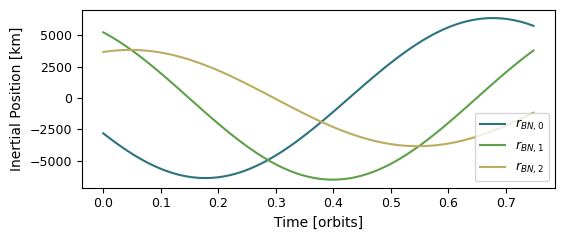

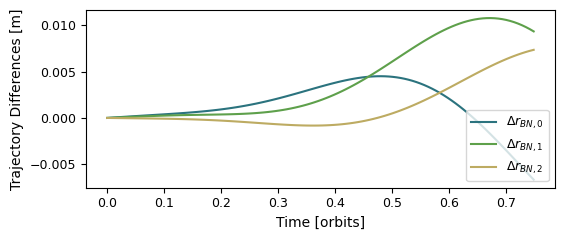

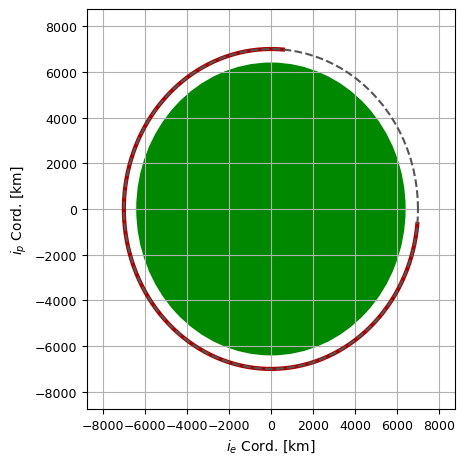

In [9]:


r"""

.. raw:: html

    <iframe width="560" height="315" src="https://www.youtube.com/embed/71ZFeameBcU" frameborder="0" allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture" allowfullscreen></iframe>

Overview
--------

This scenario demonstrates how to set up a spacecraft orbiting a celestial body. The gravity can be a first order
approximation or run with high-order spherical harmonic terms.  The following diagram illustrates how the
Basilisk components are interconnected.

.. image:: /_images/static/test_scenarioBasicOrbit.svg
   :align: center

The script is found in the folder ``basilisk/examples`` and executed by using::

    python3 scenarioBasicOrbit.py

.. important:: This scenario is currently the most minimal example available. It doesn't make sense consider
                   returning to the :ref:`examples` before moving on.


Making a Copy of the Example Basilisk Scenario Script
-----------------------------------------------------

To play with any scenario scripts as tutorials, you should make a copy of
them into a custom folder outside of the Basilisk directory.

To copy them, first find the location of the Basilisk installation. After installing, you can find the
installed location of Basilisk by opening a python interpreter and running the commands:

.. code-block:: python

   import Basilisk
   basiliskPath = Basilisk.__path__[0]
   print basiliskPath

Copy the folder ``{basiliskPath}/examples`` into a new folder in a different directory.
Now, when you want to use a tutorial, navigate inside that folder, and edit and execute the copied integrated tests.


Enable Terminal Bar to Show Simulation Progress
-----------------------------------------------

To enable progress bar, one need to set ``showProgressBar`` data member of class SimulationBaseClass to true.

.. code-block:: python

     scSim = SimulationBaseClass.SimBaseClass()
     scSim.SetProgressBar(True)

Method ``SetProgressBar`` should be used to set variable ``showProgressBar`` as True with the above statement. After
enabling the progress bar, all the simulation run by ``scSim.ExecuteSimulation()`` will show the progress bar in the
terminal.


Vizard Visualization Option
---------------------------

If you wish to transmit the simulation data to the United based `Vizard <vizard>`_ Visualization application,
then uncomment
the following line from the python scenario script. This will cause the BSK simulation data
to be stored in a binary file inside the _VizFiles sub-folder with the scenario folder. This file can be read in by
`Vizard <vizard>`_ and played back after running the BSK simulation. ::

    vizSupport.enableUnityVisualization(scSim, simTaskName, simProcessName, gravBodies=gravFactory, saveFile=fileName)

The vizInterface module must be built into BSK. This is done if the correct `CMake options <cmakeOptions>`_
are selected. The default
CMake will include this vizInterface module in the BSK build. See the BSK HTML documentation on more
information of CMake options. By using the gravFactory support class to create and add planetary bodies
the vizInterface module will automatically be able to find the correct celestial body ephemeris names.
If these names are changed, then the vizSupport.py support library has to be customized. Currently Vizard
supports playback of stored simulation data files, as well as streaming the data directly to Vizard.
By default the Viz is running in realtime mode with a 1x
speed up factor of the data playback. On the bottom right of the Vizard GUI this can be increased or decreased.
Further, some display elements such as thruster or reaction wheel panels are only visible if such devices are
being simulated in BSK.

While Vizard has many visualization features that can be customized from within the application, many
Vizard settings can also be scripted from the Basilisk python script.
A complete discussion on these options and features can be found the the `Vizard Settings <vizardSettings>`_ page.


Illustration of Simulation Results
----------------------------------

The following images illustrate the expected simulation run returns for a range of script configurations.

::

    show_plots = True, orbitCase='LEO', useSphericalHarmonics=False, planetCase='Earth'

This scenario places the spacecraft about the Earth in a LEO orbit and without considering gravitational
spherical harmonics.

.. image:: /_images/Scenarios/scenarioBasicOrbit1LEO0Earth.svg
   :align: center

.. image:: /_images/Scenarios/scenarioBasicOrbit2LEO0Earth.svg
   :align: center

.. image:: /_images/Scenarios/scenarioBasicOrbit3LEO0Earth.svg
   :align: center

::

    show_plots = True, orbitCase='GTO', useSphericalHarmonics=False, planetCase='Earth'

This case illustrates an elliptical Geosynchronous Transfer Orbit (GTO) with zero orbit inclination.

.. image:: /_images/Scenarios/scenarioBasicOrbit1GTO0Earth.svg
   :align: center

.. image:: /_images/Scenarios/scenarioBasicOrbit2GTO0Earth.svg
   :align: center

.. image:: /_images/Scenarios/scenarioBasicOrbit3GTO0Earth.svg
   :align: center

::

    show_plots = True, orbitCase='GEO', useSphericalHarmonics=False, planetCase='Earth'

This case illustrates a circular Geosynchronous Orbit (GEO) with zero orbit inclination.

.. image:: /_images/Scenarios/scenarioBasicOrbit1GEO0Earth.svg
   :align: center

.. image:: /_images/Scenarios/scenarioBasicOrbit2GEO0Earth.svg
   :align: center

.. image:: /_images/Scenarios/scenarioBasicOrbit3GEO0Earth.svg
   :align: center

::

    show_plots = True, orbitCase='LEO', useSphericalHarmonics=True, planetCase='Earth'

This case illustrates a circular LEO with a non-zero orbit inclination.
In this case the Earth's spherical harmonics are turned on.

.. image:: /_images/Scenarios/scenarioBasicOrbit1LEO1Earth.svg
   :align: center

.. image:: /_images/Scenarios/scenarioBasicOrbit2LEO1Earth.svg
   :align: center

::

    show_plots = True, orbitCase='LEO', useSphericalHarmonics=True, planetCase='Mars'

This case illustrates a circular Low Mars Orbit or LMO with a non-zero orbit inclination.
In this simulation setup the planet's spherical harmonics are turned on.

.. image:: /_images/Scenarios/scenarioBasicOrbit1LEO0Mars.svg
   :align: center

.. image:: /_images/Scenarios/scenarioBasicOrbit2LEO0Mars.svg
   :align: center

.. image:: /_images/Scenarios/scenarioBasicOrbit3LEO0Mars.svg
   :align: center

"""



#
# Basilisk Scenario Script and Integrated Test
#
# Purpose:  Integrated test of the spacecraft() and gravity modules.  Illustrates
#           a 3-DOV spacecraft on a range of orbit types.
# Author:   Hanspeter Schaub
# Creation Date:  Nov. 26, 2016
#

import os
from copy import copy

import matplotlib.pyplot as plt
import numpy as np
# To play with any scenario scripts as tutorials, you should make a copy of them into a custom folder
# outside of the Basilisk directory.
#
# To copy them, first find the location of the Basilisk installation.
# After installing, you can find the installed location of Basilisk by opening a python interpreter and
# running the commands:
from Basilisk import __path__ as bskPathList

bskPath = bskPathList[0]
fileName = os.path.basename(os.path.normpath(bskPath))

# Copy the folder `{basiliskPath}/examples` into a new folder in a different directory.
# Now, when you want to use a tutorial, navigate inside that folder, and edit and execute the *copied* integrated tests.


# import simulation related support
from Basilisk.simulation import spacecraft
# general support file with common unit test functions
# import general simulation support files
from Basilisk.utilities import (SimulationBaseClass, macros, orbitalMotion,
                                simIncludeGravBody, unitTestSupport, vizSupport)

# always import the Basilisk messaging support



def run(show_plots, orbitCase, useSphericalHarmonics, planetCase):
    """
    At the end of the python script you can specify the following example parameters.

    Args:
        show_plots (bool): Determines if the script should display plots
        orbitCase (str):

            ======  ============================
            String  Definition
            ======  ============================
            'LEO'   Low Earth Orbit
            'GEO'   Geosynchronous Orbit
            'GTO'   Geostationary Transfer Orbit
            ======  ============================

        useSphericalHarmonics (Bool): False to use first order gravity approximation: :math:`\\frac{GMm}{r^2}`

        planetCase (str): {'Earth', 'Mars'}
    """

    # Create simulation variable names
    simTaskName = "simTask"
    simProcessName = "simProcess"

    #  Create a sim module as an empty container
    scSim = SimulationBaseClass.SimBaseClass()

    # (Optional) If you want to see a simulation progress bar in the terminal window, the
    # use the following SetProgressBar(True) statement
    scSim.SetProgressBar(True)

    #  create the simulation process
    dynProcess = scSim.CreateNewProcess(simProcessName)

    # create the dynamics task and specify the integration update time
    simulationTimeStep = macros.sec2nano(10.)
    dynProcess.addTask(scSim.CreateNewTask(simTaskName, simulationTimeStep))

    # setup the simulation tasks/objects
    # initialize spacecraft object and set properties
    # The dynamics simulation is setup using a Spacecraft() module.
    scObject = spacecraft.Spacecraft()
    scObject.ModelTag = "bsk-Sat"

    # add spacecraft object to the simulation process
    scSim.AddModelToTask(simTaskName, scObject)

    # setup Gravity Body
    # The first step to adding gravity objects is to create the gravity body factor class.  Note that
    # this call will create an empty gravitational body list each time this script is called.  Thus, there
    # is not need to clear any prior list of gravitational bodies.
    gravFactory = simIncludeGravBody.gravBodyFactory()

    # To attach an Earth or Mars gravity model to this spacecraft, the following macros  invoked.
    # The gravFactor() class stores the Earth gravitational object within the class, but it also returns a
    # handler to this gravitational object as a convenience.  The celestial object position and velocity
    # vectors are all defaulted to zero values.  If non-zero values are required, this can be manually
    # overridden.  If multiple bodies are simulated, then their positions can be
    # dynamically updated.  See scenarioOrbitMultiBody.py to learn how this is
    # done via a SPICE object.
    if planetCase == 'Mars':
        planet = gravFactory.createMarsBarycenter()
        planet.isCentralBody = True           # ensure this is the central gravitational body
        if useSphericalHarmonics:
            planet.useSphericalHarmonicsGravityModel(bskPath + '/supportData/LocalGravData/GGM2BData.txt', 100)

    else:  # Earth
        planet = gravFactory.createEarth()
        planet.isCentralBody = True          # ensure this is the central gravitational body
        if useSphericalHarmonics:
            # If extra customization is required, see the createEarth() macro to change additional values.
            # For example, the spherical harmonics are turned off by default.  To engage them, the following code
            # is used
            planet.useSphericalHarmonicsGravityModel(bskPath + '/supportData/LocalGravData/GGM03S-J2-only.txt', 2)

            # The value 2 indicates that the first two harmonics, excluding the 0th order harmonic,
            # are included.  This harmonics data file only includes a zeroth order and J2 term.
    mu = planet.mu

    # Finally, the gravitational body must be connected to the spacecraft object.  This is done with
    gravFactory.addBodiesTo(scObject)
    # Here the complete list of gravitational bodies is automatically assigned to the spacecraft, regardless if
    # it is only one body like Earth or Mars, or a list of multiple bodies.

    # Note that the default planets position and velocity vectors in the gravitational body are set to zero.  If
    # alternate position or velocity vectors are required, this can be done by creating the planet ephemeris message
    # that is connected to the gravity effector input message `planetBodyInMsg`.
    # If time varying planet ephemeris messages are to be included use the Spice module.  For non-zero messages
    # the planet's default ephemeris would be replaced with the desired custom values.

    #
    #   setup orbit and simulation time
    #
    # setup the orbit using classical orbit elements
    oe = orbitalMotion.ClassicElements()
    rLEO = 7000. * 1000      # meters
    rGEO = 42000. * 1000     # meters
    if orbitCase == 'GEO':
        oe.a = rGEO
        oe.e = 0.00001
        oe.i = 0.0 * macros.D2R
    elif orbitCase == 'GTO':
        oe.a = (rLEO + rGEO) / 2.0
        oe.e = 1.0 - rLEO / oe.a
        oe.i = 0.0 * macros.D2R
    else:                   # LEO case, default case 0
        oe.a = rLEO
        oe.e = 0.0001
        oe.i = 33.3 * macros.D2R
    oe.Omega = 48.2 * macros.D2R
    oe.omega = 347.8 * macros.D2R
    oe.f = 85.3 * macros.D2R
    rN, vN = orbitalMotion.elem2rv(mu, oe)
    oe = orbitalMotion.rv2elem(mu, rN, vN)      # this stores consistent initial orbit elements
    # with circular or equatorial orbit, some angles are arbitrary


    # To set the spacecraft initial conditions, the following initial position and velocity variables are set:
    scObject.hub.r_CN_NInit = rN  # m   - r_BN_N
    scObject.hub.v_CN_NInit = vN  # m/s - v_BN_N

    # These vectors specify the inertial position and velocity vectors relative to the planet of the
    # spacecraft center of mass location.  Note that there are 2 points that can be tracked.  The user always
    # specifies the spacecraft center of mass location with the above code.  If the simulation output should be
    # about another body fixed point B, this can be done as well.  This is useful in particular with more challenging
    # dynamics where the center of mass moves relative to the body.  The following vector would specify the location of
    # the spacecraft hub center of mass (Bc) relative to this body fixed point, as in
    #
    #    scObject.hub.r_BcB_B = [[0.0], [0.0], [1.0]]
    #

    # If this vector is not specified, as in this tutorial scenario, then it defaults to zero.  If only a rigid hub
    # is modeled, the Bc (hub center of mass) is the same as C (spacecraft center of mass).  If the spacecraft contains
    # state effectors such as hinged panels, fuel slosh, imbalanced reaction wheels, etc., then the points
    # Bc and C would not be the same.  Thus, in this simple simulation the body fixed point B and
    # spacecraft center of mass are identical.

    # set the simulation time
    n = np.sqrt(mu / oe.a / oe.a / oe.a)
    P = 2. * np.pi / n
    if useSphericalHarmonics:
        simulationTime = macros.sec2nano(3. * P)
    else:
        simulationTime = macros.sec2nano(0.75 * P)

    # Setup data logging before the simulation is initialized
    if useSphericalHarmonics:
        numDataPoints = 400
    else:
        numDataPoints = 100
    # The msg recorder can be told to sample at an with a minimum hold period in nano-seconds.
    # If no argument is provided, i.e. msg.recorder(), then a default 0ns minimum time period is used
    # which causes the msg to be recorded on every task update rate.
    # The recorder can be put onto a separate task with its own update rate.  However, this can be
    # trickier to do as the recording timing must be carefully balanced with the module msg writing
    # to avoid recording an older message.
    samplingTime = unitTestSupport.samplingTime(simulationTime, simulationTimeStep, numDataPoints)
    # create a logging task object of the spacecraft output message at the desired down sampling ratio
    dataRec = scObject.scStateOutMsg.recorder(samplingTime)
    scSim.AddModelToTask(simTaskName, dataRec)

    # Vizard Visualization Option
    # ---------------------------
    # If you wish to transmit the simulation data to the United based Vizard Visualization application,
    # then uncomment the following
    # line from the python scenario script.  This will cause the BSK simulation data to
    # be stored in a binary file inside the _VizFiles sub-folder with the scenario folder.  This file can be read in by
    # Vizard and played back after running the BSK simulation.
    # To enable this, uncomment this line:

    viz = vizSupport.enableUnityVisualization(scSim, simTaskName, scObject,
                                              # saveFile=__file__
                                              # liveStream=True
                                              )

    # The vizInterface module must be built into BSK.  This is done if the correct CMake options are selected.
    # The default CMake will include this vizInterface module in the BSK build.  See the BSK HTML documentation on
    # more information of CMake options.

    # By using the gravFactory support class to create and add planetary bodies the vizInterface module will
    # automatically be able to find the correct celestial body ephemeris names.  If these names are changed, then the
    # vizSupport.py support library has to be customized.
    # Currently Vizard supports playback of stored simulation data files as well as live streaming.
    # Further, some display elements such as thruster or reaction wheel panels are only visible if
    # such devices are being simulated in BSK.

    # While Vizard has many visualization features that can be customized from within the application, many Vizard
    # settings can also be scripted from the Basilisk python script.  A complete discussion on these options and
    # features can be found the the Vizard documentation pages.

    # Before the simulation is ready to run, it must be initialized.  The following code uses a
    # convenient macro routine
    # which initializes each BSK module (run self init, cross init and reset) and clears the BSK logging stack.

    #   initialize Simulation:  This function runs the self_init()
    #   and reset() routines on each module.
    scSim.InitializeSimulation()

    #   configure a simulation stop time and execute the simulation run
    scSim.ConfigureStopTime(simulationTime)
    scSim.ExecuteSimulation()
    # Note that this module simulates both the translational and rotational motion of the spacecraft.
    # In this scenario only the translational (i.e. orbital) motion is tracked.  This means the rotational motion
    # remains at a default inertial frame orientation in this scenario.  There is no appreciable speed hit to
    # simulate both the orbital and rotational motion for a single rigid body.  In the later scenarios
    # the rotational motion is engaged by specifying rotational initial conditions, as well as rotation
    # related effectors.  In this simple scenario only translational motion is setup and tracked.
    # Further, the default spacecraft parameters, such as the unit mass and the principle inertia values are
    # just fine for this orbit simulation as they don't impact the orbital dynamics in this case.
    # This is true for all gravity force only orbital simulations. Later
    # tutorials, such as scenarioAttitudeFeedback.py,
    # illustrate how to over-ride default values with desired simulation values.

    #   retrieve the logged data
    # the data is stored inside dataLog variable.  The time axis is stored separately from the data vector and
    # can be access through dataLog.times().  The message data is access directly through the message
    # variable names.
    posData = dataRec.r_BN_N
    velData = dataRec.v_BN_N

    np.set_printoptions(precision=16)

    # When the simulation completes 2 plots are shown for each case.  One plot always shows
    # the inertial position vector components, while the second plot either shows a planar
    # orbit view relative to the peri-focal frame (no spherical harmonics), or the
    # semi-major axis time history plot (with spherical harmonics turned on).
    figureList, finalDiff = plotOrbits(dataRec.times(), posData, velData, oe, mu, P,
                            orbitCase, useSphericalHarmonics, planetCase, planet)

    if show_plots:
        plt.show()

    # close the plots being saved off to avoid over-writing old and new figures
    plt.close("all")

    return finalDiff, figureList



def plotOrbits(timeAxis, posData, velData, oe, mu, P, orbitCase, useSphericalHarmonics, planetCase, planet):
    # draw the inertial position vector components
    plt.close("all")  # clears out plots from earlier test runs
    plt.figure(1)
    fig = plt.gcf()
    ax = fig.gca()
    ax.ticklabel_format(useOffset=False, style='plain')
    finalDiff = 0.0

    for idx in range(3):
        plt.plot(timeAxis * macros.NANO2SEC / P, posData[:, idx] / 1000.,
                 color=unitTestSupport.getLineColor(idx, 3),
                 label='$r_{BN,' + str(idx) + '}$')
    plt.legend(loc='lower right')
    plt.xlabel('Time [orbits]')
    plt.ylabel('Inertial Position [km]')
    figureList = {}
    pltName = fileName + "1" + orbitCase + str(int(useSphericalHarmonics)) + planetCase
    figureList[pltName] = plt.figure(1)

    if useSphericalHarmonics is False:
        # draw orbit in perifocal frame
        b = oe.a * np.sqrt(1 - oe.e * oe.e)
        p = oe.a * (1 - oe.e * oe.e)
        plt.figure(2, figsize=tuple(np.array((1.0, b / oe.a)) * 4.75), dpi=100)
        plt.axis(np.array([-oe.rApoap, oe.rPeriap, -b, b]) / 1000 * 1.25)
        # draw the planet
        fig = plt.gcf()
        ax = fig.gca()
        if planetCase == 'Mars':
            planetColor = '#884400'
        else:
            planetColor = '#008800'
        planetRadius = planet.radEquator / 1000
        ax.add_artist(plt.Circle((0, 0), planetRadius, color=planetColor))
        # draw the actual orbit
        rData = []
        fData = []
        for idx in range(0, len(posData)):
            oeData = orbitalMotion.rv2elem(mu, posData[idx], velData[idx])
            rData.append(oeData.rmag)
            fData.append(oeData.f + oeData.omega - oe.omega)
        plt.plot(rData * np.cos(fData) / 1000, rData * np.sin(fData) / 1000, color='#aa0000', linewidth=3.0
                 )
        # draw the full osculating orbit from the initial conditions
        fData = np.linspace(0, 2 * np.pi, 100)
        rData = []
        for idx in range(0, len(fData)):
            rData.append(p / (1 + oe.e * np.cos(fData[idx])))
        plt.plot(rData * np.cos(fData) / 1000, rData * np.sin(fData) / 1000, '--', color='#555555'
                 )
        plt.xlabel('$i_e$ Cord. [km]')
        plt.ylabel('$i_p$ Cord. [km]')
        plt.grid()

        plt.figure(3)
        fig = plt.gcf()
        ax = fig.gca()
        ax.ticklabel_format(useOffset=False, style='plain')
        Deltar = np.empty((0, 3))
        E0 = orbitalMotion.f2E(oe.f, oe.e)
        M0 = orbitalMotion.E2M(E0, oe.e)
        n = np.sqrt(mu/(oe.a*oe.a*oe.a))
        oe2 = copy(oe)
        for idx in range(0, len(posData)):
            M = M0 + n * timeAxis[idx] * macros.NANO2SEC
            Et = orbitalMotion.M2E(M, oe.e)
            oe2.f = orbitalMotion.E2f(Et, oe.e)
            rv, vv = orbitalMotion.elem2rv(mu, oe2)
            Deltar = np.append(Deltar, [posData[idx] - rv], axis=0)
        for idx in range(3):
            plt.plot(timeAxis * macros.NANO2SEC / P, Deltar[:, idx] ,
                     color=unitTestSupport.getLineColor(idx, 3),
                     label=r'$\Delta r_{BN,' + str(idx) + '}$')
        plt.legend(loc='lower right')
        plt.xlabel('Time [orbits]')
        plt.ylabel('Trajectory Differences [m]')
        pltName = fileName + "3" + orbitCase + str(int(useSphericalHarmonics)) + planetCase
        figureList[pltName] = plt.figure(3)

        finalDiff = np.linalg.norm(Deltar[-1])

    else:
        plt.figure(2)
        fig = plt.gcf()
        ax = fig.gca()
        ax.ticklabel_format(useOffset=False, style='plain')
        smaData = []
        for idx in range(0, len(posData)):
            oeData = orbitalMotion.rv2elem(mu, posData[idx], velData[idx])
            smaData.append(oeData.a / 1000.)
        plt.plot(timeAxis * macros.NANO2SEC / P, smaData, color='#aa0000',
                 )
        plt.xlabel('Time [orbits]')
        plt.ylabel('SMA [km]')

    pltName = fileName + "2" + orbitCase + str(int(useSphericalHarmonics)) + planetCase
    figureList[pltName] = plt.figure(2)
    return figureList, finalDiff

if __name__ == "__main__":
    run(
        True,        # show_plots
        'LEO',       # orbit Case (LEO, GTO, GEO)
        False,       # useSphericalHarmonics
        'Earth'      # planetCase (Earth, Mars)
    )

In [3]:
import Basilisk
basiliskPath = Basilisk.__path__[0]
print(basiliskPath)

C:\Users\bobby\Documents\Basilisk\dist3\Basilisk
